In [1]:
import os
import re
import json
import kagglehub
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
import matplotlib.pyplot as plt
import seaborn as sns

/home/mastermind/ielts_pred/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-01 11:22:12.839022: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from pathlib import Path
import kagglehub
import torch

project_root = Path.cwd()
path = Path(kagglehub.dataset_download("mazlumi/ielts-writing-scored-essays-dataset"))

(model_dir := project_root / "models").mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH = model_dir / "bert_ielts_model_v3.pt"

BERT_MODEL = "distilbert-base-uncased"
MAX_SEQ_LEN = 256
BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 4
EPOCHS = 8
LEARNING_RATE = 1.5e-5
WEIGHT_DECAY = 0.02
DROPOUT = 0.35
FREEZE_BERT_LAYERS = 3
WARMUP_STEPS = 100
EARLY_STOP_PATIENCE = 6
LABEL_SMOOTHING = 0.05

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Model save path:", MODEL_SAVE_PATH)

Device: cuda
Model save path: /home/mastermind/ielts_pred/src/notebooks/models/bert_ielts_model_v3.pt


In [3]:
from pathlib import Path

csv_path = Path(path) / "ielts_writing_dataset.csv"
df = pd.read_csv(csv_path)
df.head()

,Task_Type,Question,Essay,Examiner_Commen,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall
0,1,The bar chart below describes some changes abo...,"Between 1995 and 2010, a study was conducted r...",NaN,NaN,NaN,NaN,NaN,5.5
1,2,Rich countries often give money to poorer coun...,Poverty represents a worldwide crisis. It is t...,NaN,NaN,NaN,NaN,NaN,6.5
2,1,The bar chart below describes some changes abo...,The left chart shows the population change hap...,NaN,NaN,NaN,NaN,NaN,5.0
3,2,Rich countries often give money to poorer coun...,Human beings are facing many challenges nowada...,NaN,NaN,NaN,NaN,NaN,5.5
4,1,The graph below shows the number of overseas v...,Information about the thousands of visits from...,NaN,NaN,NaN,NaN,NaN,7.0


In [4]:
df = df[["Essay", "Overall"]].dropna() 
df = df[~df.duplicated(subset=["Essay"], keep="first")].reset_index(drop=True)
df["Scaled"] = df["Overall"] / 9.0
df.head()


,Essay,Overall,Scaled
0,"Between 1995 and 2010, a study was conducted r...",5.5,0.611111
1,Poverty represents a worldwide crisis. It is t...,6.5,0.722222
2,The left chart shows the population change hap...,5.0,0.555556
3,Human beings are facing many challenges nowada...,5.5,0.611111
4,Information about the thousands of visits from...,7.0,0.777778


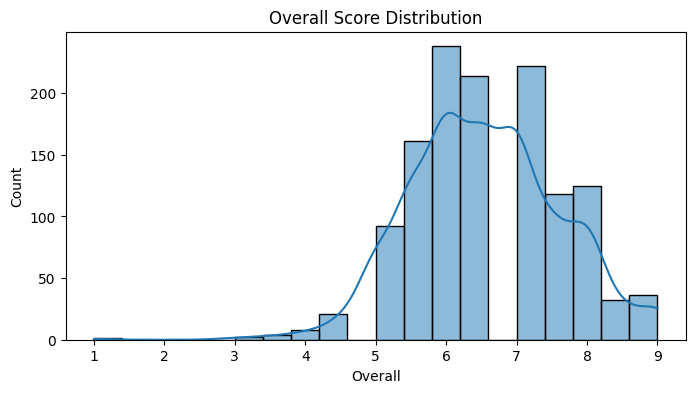

In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Overall"], bins=20, kde=True)
plt.title("Overall Score Distribution")
plt.xlabel("Overall")
plt.ylabel("Count")
plt.show()

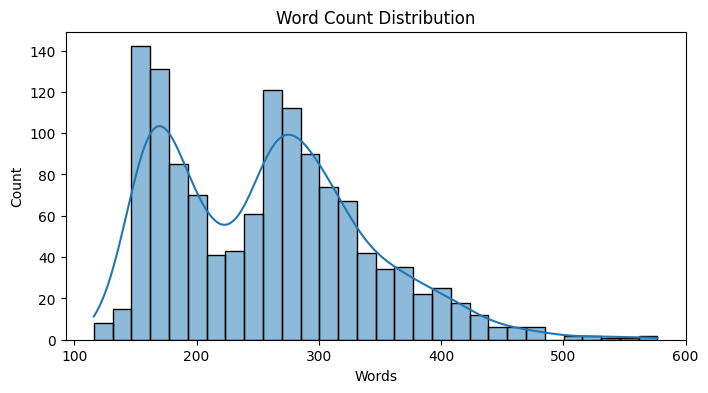

In [6]:
df["word_count"] = df["Essay"].str.split().apply(len)
plt.figure(figsize=(8, 4))
sns.histplot(df["word_count"], bins=30, kde=True)
plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()

In [7]:
def extract_linguistic_features(essay: str) -> np.ndarray:
    words = essay.split()
    sentences = re.split(r"[.!?]+", essay)
    sentences = [s.strip() for s in sentences if s.strip()]

    features = [
        len(words),
        len(sentences) if sentences else 1,
        len(words) / max(len(sentences), 1),
        len(set(w.lower() for w in words)) / max(len(words), 1),
        len(essay),
        sum(1 for c in essay if c.isupper()) / max(len(essay), 1),
        essay.count(",") / max(len(words), 1),
        essay.count(".") / max(len(sentences), 1),
        sum(len(w) for w in words) / max(len(words), 1),
        sum(1 for w in words if w.lower() in {
            "however","moreover","furthermore","therefore","consequently",
            "nevertheless","additionally","specifically","particularly"
        }) / max(len(words), 1)
    ]
    return np.array(features, dtype="float32")

def normalise_features(features_list):
    features = np.array(features_list)
    mean = features.mean(axis=0)
    std = features.std(axis=0) + 1e-8
    normalized = (features - mean) / std
    return normalized, mean, std

In [8]:
bins = pd.qcut(df["Overall"], q=5, duplicates="drop")
bin_counts = bins.value_counts()
valid_bins = bin_counts[bin_counts >= 2].index
mask = bins.isin(valid_bins)

df_safe = df[mask].copy()
bins_safe = pd.qcut(df_safe["Overall"], q=min(5, df_safe["Overall"].nunique()), duplicates="drop")

train_df, val_df = train_test_split(
    df_safe,
    test_size=0.18,
    random_state=42,
    stratify=bins_safe
)
print("Train:", len(train_df))
print("Val:", len(val_df))

Train: 1044
Val: 230


In [9]:
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

def tokenise_essays(essays, max_len=MAX_SEQ_LEN):
    if hasattr(essays, "tolist"):
        essays = essays.tolist()
    encoded = tokenizer(
        essays,
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_tensors=None
    )
    input_ids = torch.tensor(encoded["input_ids"], dtype=torch.long)
    attention_mask = torch.tensor(encoded["attention_mask"], dtype=torch.long)
    return input_ids, attention_mask

X_train_ids, X_train_mask = tokenise_essays(train_df["Essay"])
X_val_ids, X_val_mask = tokenise_essays(val_df["Essay"])

/home/mastermind/ielts_pred/venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [10]:
train_features = [extract_linguistic_features(e) for e in train_df["Essay"].values]
val_features = [extract_linguistic_features(e) for e in val_df["Essay"].values]

train_features_norm, feat_mean, feat_std = normalise_features(train_features)
val_features_norm = (np.array(val_features) - feat_mean) / feat_std

# Save normalization stats
np.save(os.path.join(project_root, "bert_features_mean_v3.npy"), feat_mean)
np.save(os.path.join(project_root, "bert_features_std_v3.npy"), feat_std)

X_train_feat = torch.tensor(train_features_norm, dtype=torch.float32)
X_val_feat = torch.tensor(val_features_norm, dtype=torch.float32)

y_train = torch.tensor(train_df["Scaled"].values, dtype=torch.float32)
y_val = torch.tensor(val_df["Scaled"].values, dtype=torch.float32)

In [11]:
train_dataset = TensorDataset(X_train_ids, X_train_mask, X_train_feat, y_train)
val_dataset = TensorDataset(X_val_ids, X_val_mask, X_val_feat, y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

In [12]:
class BERTIELTSScorer(nn.Module):
    def __init__(self, bert_model_name=BERT_MODEL, num_features=10, dropout=0.35, freeze_bert_layers=2):
        super().__init__()
        self.bert = AutoModel.from_pretrained(bert_model_name)

        if freeze_bert_layers > 0:
            for i, layer in enumerate(self.bert.transformer.layer):
                if i < freeze_bert_layers:
                    for param in layer.parameters():
                        param.requires_grad = False

        self.bert_hidden_size = self.bert.config.hidden_size
        self.feature_network = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(dropout * 0.7)
        )
        combined_size = self.bert_hidden_size + 32
        self.prediction_head = nn.Sequential(
            nn.Linear(combined_size, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout * 0.7),
            nn.Linear(64, 1)
        )

    def forward(self, input_ids, attention_mask, features):
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = bert_output.last_hidden_state[:, 0, :]
        feature_embedding = self.feature_network(features)
        combined = torch.cat([cls_embedding, feature_embedding], dim=-1)
        return self.prediction_head(combined).squeeze(-1)

model = BERTIELTSScorer(
    bert_model_name=BERT_MODEL,
    num_features=10,
    dropout=DROPOUT,
    freeze_bert_layers=FREEZE_BERT_LAYERS
).to(device)

In [13]:
class SmoothL1WithLabelSmoothing(nn.Module):
    def __init__(self, beta=0.08, smoothing=0.05):
        super().__init__()
        self.beta = beta
        self.smoothing = smoothing

    def forward(self, pred, target):
        if self.smoothing > 0:
            noise = torch.randn_like(target) * self.smoothing
            target = (target + noise).clamp(0, 1)
        diff = torch.abs(pred - target)
        loss = torch.where(diff < self.beta, 0.5 * diff ** 2 / self.beta, diff - 0.5 * self.beta)
        return loss.mean()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

total_steps = len(train_loader) * EPOCHS // GRADIENT_ACCUMULATION_STEPS
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

loss_fn = SmoothL1WithLabelSmoothing(beta=0.08, smoothing=LABEL_SMOOTHING)

In [14]:
from tqdm.auto import tqdm

best_val_mae = float("inf")
epochs_without_improvement = 0
train_mae_history, val_mae_history = [], []

for epoch in range(EPOCHS):
    model.train()
    train_preds, train_targets = [], []
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    for i, (ids, mask, feat, yb) in enumerate(pbar):
        ids, mask, feat, yb = ids.to(device), mask.to(device), feat.to(device), yb.to(device)

        preds = model(ids, mask, feat)
        loss = loss_fn(preds, yb) / GRADIENT_ACCUMULATION_STEPS
        loss.backward()

        if (i + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        train_preds.extend(preds.detach().cpu().numpy())
        train_targets.extend(yb.cpu().numpy())

        if (i + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
            pbar.set_postfix(loss=f"{loss.item() * GRADIENT_ACCUMULATION_STEPS:.4f}")

    train_mae = np.mean(np.abs(np.array(train_preds) - np.array(train_targets)))
    train_mae_history.append(train_mae)

    model.eval()
    val_preds, val_targets = [], []
    with torch.no_grad():
        for ids, mask, feat, yb in val_loader:
            ids, mask, feat, yb = ids.to(device), mask.to(device), feat.to(device), yb.to(device)
            preds = model(ids, mask, feat)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(yb.cpu().numpy())

    val_mae = np.mean(np.abs(np.array(val_preds) - np.array(val_targets)))
    val_mae_history.append(val_mae)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train MAE: {train_mae:.4f} | Val MAE: {val_mae:.4f}")

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        epochs_without_improvement = 0
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "best_val_mae": best_val_mae,
            "bert_model_name": BERT_MODEL,
        }, MODEL_SAVE_PATH)
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print("Early stopping.")
        break

Epoch 1/8 | Train MAE: 0.5867 | Val MAE: 0.1824


Epoch 2/8 | Train MAE: 0.2263 | Val MAE: 0.1461


Epoch 3/8 | Train MAE: 0.1781 | Val MAE: 0.1061


Epoch 4/8 | Train MAE: 0.1737 | Val MAE: 0.0974


Epoch 5/8 | Train MAE: 0.1627 | Val MAE: 0.0837


Epoch 6/8 | Train MAE: 0.1528 | Val MAE: 0.0903


Epoch 7/8 | Train MAE: 0.1497 | Val MAE: 0.0837


Epoch 8/8 | Train MAE: 0.1558 | Val MAE: 0.0877


In [15]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, confusion_matrix
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
from pathlib import Path

In [16]:
project_root = Path.cwd()
(model_dir := project_root / "models").mkdir(parents=True, exist_ok=True)

MODEL_SAVE_PATH = model_dir / "bert_ielts_model_v3.pt"
FEATURES_MEAN_PATH = project_root / "bert_features_mean_v3.npy"
FEATURES_STD_PATH = project_root / "bert_features_std_v3.npy"

print("Saving model to:", MODEL_SAVE_PATH)

MAX_SEQ_LEN = 256
BATCH_SIZE = 8
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Saving model to: /home/mastermind/ielts_pred/src/notebooks/models/bert_ielts_model_v3.pt
Device: cuda


In [17]:
def extract_linguistic_features(essay: str) -> np.ndarray:
    words = essay.split()
    sentences = re.split(r"[.!?]+", essay)
    sentences = [s.strip() for s in sentences if s.strip()]

    features = [
        len(words),
        len(sentences) if sentences else 1,
        len(words) / max(len(sentences), 1),
        len(set(w.lower() for w in words)) / max(len(words), 1),
        len(essay),
        sum(1 for c in essay if c.isupper()) / max(len(essay), 1),
        essay.count(",") / max(len(words), 1),
        essay.count(".") / max(len(sentences), 1),
        sum(len(w) for w in words) / max(len(words), 1),
        sum(1 for w in words if w.lower() in {
            "however","moreover","furthermore","therefore","consequently",
            "nevertheless","additionally","specifically","particularly"
        }) / max(len(words), 1)
    ]
    return np.array(features, dtype="float32")

In [18]:
class IELTSDataset(Dataset):
    def __init__(self, essays, scores):
        self.essays = essays
        self.scores = scores

    def __len__(self):
        return len(self.essays)

    def __getitem__(self, idx):
        return self.essays[idx], self.scores[idx]


def create_collate_fn(tokenizer, feat_mean, feat_std, max_len=256):
    def collate_batch(batch):
        essays, scores = zip(*batch)

        encoded = tokenizer(
            list(essays),
            max_length=max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        features = np.array([extract_linguistic_features(e) for e in essays])
        features_norm = (features - feat_mean) / feat_std
        X_feat = torch.tensor(features_norm, dtype=torch.float32)
        y = torch.tensor(scores, dtype=torch.float32)

        return encoded["input_ids"], encoded["attention_mask"], X_feat, y
    return collate_batch

In [19]:
class BERTIELTSScorer(nn.Module):
    def __init__(self, bert_model_name="distilbert-base-uncased", num_features=10, dropout=0.35, freeze_bert_layers=3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(bert_model_name)
        if freeze_bert_layers > 0:
            for i, layer in enumerate(self.bert.transformer.layer):
                if i < freeze_bert_layers:
                    for p in layer.parameters():
                        p.requires_grad = False

        self.bert_hidden_size = self.bert.config.hidden_size
        self.feature_network = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(dropout * 0.7)
        )
        combined_size = self.bert_hidden_size + 32
        self.prediction_head = nn.Sequential(
            nn.Linear(combined_size, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout * 0.7),
            nn.Linear(64, 1)
        )

    def forward(self, input_ids, attention_mask, features):
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = bert_output.last_hidden_state[:, 0, :]
        feature_embedding = self.feature_network(features)
        combined = torch.cat([cls_embedding, feature_embedding], dim=-1)
        return self.prediction_head(combined).squeeze(-1)

In [20]:
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
bert_model_name = checkpoint.get("bert_model_name", "distilbert-base-uncased")

tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
model = BERTIELTSScorer(bert_model_name=bert_model_name, dropout=0.35, freeze_bert_layers=3)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

feat_mean = np.load(FEATURES_MEAN_PATH)
feat_std = np.load(FEATURES_STD_PATH)

print("Model loaded:", bert_model_name)

Model loaded: distilbert-base-uncased


In [22]:
csv_path = os.path.join(path, "ielts_writing_dataset.csv")
df_eval = pd.read_csv(csv_path)
df_eval = df_eval[["Essay", "Overall"]].dropna()
df_eval = df_eval[~df_eval.duplicated(subset=["Essay"], keep="first")].reset_index(drop=True)

# Robust stratification: ensure each bin has at least 2 samples
bins = pd.qcut(df_eval["Overall"], q=5, duplicates="drop")
bin_counts = bins.value_counts()
valid_bins = bin_counts[bin_counts >= 2].index
mask = bins.isin(valid_bins)
df_eval_safe = df_eval[mask].copy()
bins_safe = pd.qcut(df_eval_safe["Overall"], q=min(5, df_eval_safe["Overall"].nunique()), duplicates="drop")

train_df, test_df = train_test_split(
    df_eval_safe,
    test_size=0.18,
    random_state=42,
    stratify=bins_safe,
 )

collate_fn = create_collate_fn(tokenizer, feat_mean, feat_std, MAX_SEQ_LEN)
train_loader = DataLoader(IELTSDataset(train_df["Essay"].values, train_df["Overall"].values),
                          batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(IELTSDataset(test_df["Essay"].values, test_df["Overall"].values),
                         batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print("Train:", len(train_df), "Test:", len(test_df))

Train: 1044 Test: 230


In [23]:
from tqdm.auto import tqdm

def evaluate_dataset(model, dataloader, name="Dataset"):
    model.eval()
    all_preds, all_true, all_preds_scaled = [], [], []

    with torch.no_grad():
        for input_ids, attention_mask, features, y in tqdm(dataloader, desc=f"Evaluating {name}"):
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            features = features.to(device)

            pred_scaled = model(input_ids, attention_mask, features)
            pred = (pred_scaled.cpu().numpy() * 9.0).clip(1, 9)

            all_preds.extend(pred)
            all_preds_scaled.extend(pred_scaled.cpu().numpy())
            all_true.extend(y.numpy())

    y_pred = np.array(all_preds)
    y_true = np.array(all_true)

    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    pearson_r, _ = pearsonr(y_true, y_pred)
    spearman_rho, _ = spearmanr(y_true, y_pred)
    within_05 = np.mean(np.abs(y_true - y_pred) <= 0.5)
    within_10 = np.mean(np.abs(y_true - y_pred) <= 1.0)

    print(f"\n{name} | MAE: {mae:.3f} | R²: {r2:.3f} | Pearson: {pearson_r:.3f} | Spearman: {spearman_rho:.3f}")
    print(f"{name} | ±0.5: {within_05:.1%} | ±1.0: {within_10:.1%}")

    return y_true, y_pred, {
        "mae": mae,
        "r2": r2,
        "pearson_r": pearson_r,
        "spearman_rho": spearman_rho,
        "within_05": within_05,
        "within_10": within_10,
    }

In [24]:
train_true, train_pred, train_metrics = evaluate_dataset(model, train_loader, "Train")
test_true, test_pred, test_metrics = evaluate_dataset(model, test_loader, "Test")

Evaluating Train: 100%|██████████| 131/131 [00:36<00:00,  3.60it/s]



Train | MAE: 0.757 | R²: 0.199 | Pearson: 0.613 | Spearman: 0.592
Train | ±0.5: 41.1% | ±1.0: 69.8%


Evaluating Test: 100%|██████████| 29/29 [00:08<00:00,  3.59it/s]


Test | MAE: 0.753 | R²: 0.230 | Pearson: 0.604 | Spearman: 0.566
Test | ±0.5: 40.9% | ±1.0: 69.1%


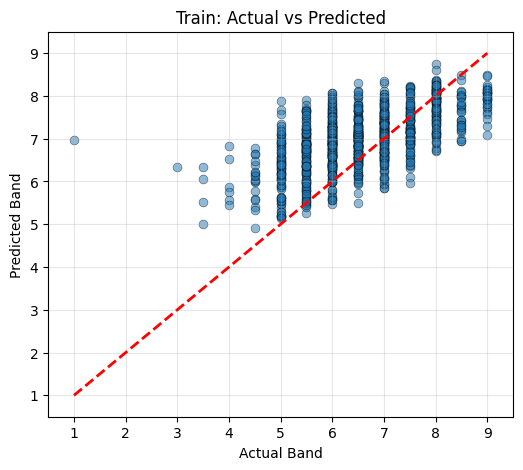

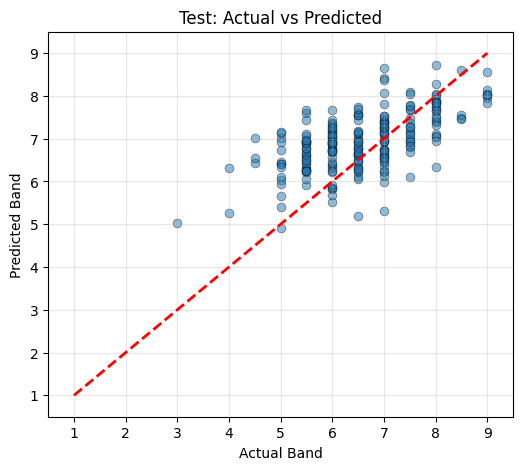

In [25]:
def plot_scatter(y_true, y_pred, title):
    plt.figure(figsize=(6, 5))
    plt.scatter(y_true, y_pred, alpha=0.5, s=40, edgecolors="black", linewidth=0.5)
    plt.plot([1, 9], [1, 9], "r--", linewidth=2)
    plt.xlabel("Actual Band")
    plt.ylabel("Predicted Band")
    plt.title(title)
    plt.xlim(0.5, 9.5)
    plt.ylim(0.5, 9.5)
    plt.grid(alpha=0.3)
    plt.show()

plot_scatter(train_true, train_pred, "Train: Actual vs Predicted")
plot_scatter(test_true, test_pred, "Test: Actual vs Predicted")

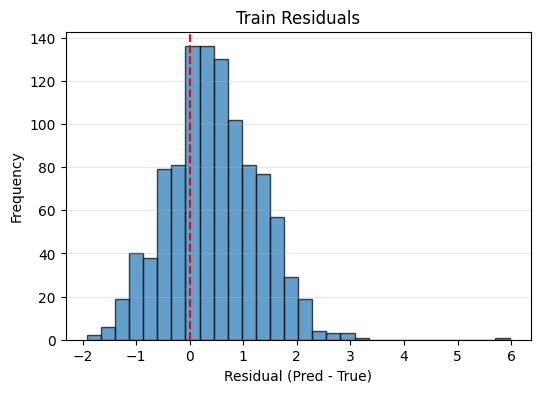

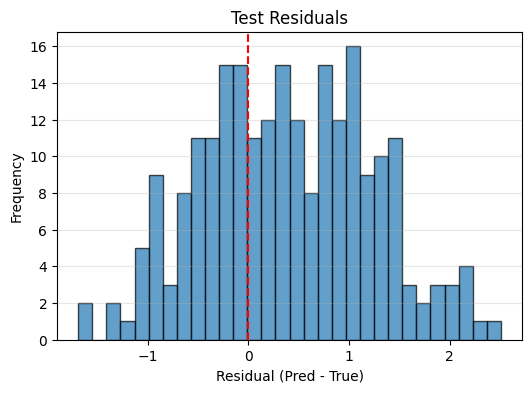

In [26]:
def plot_residuals(y_true, y_pred, title):
    residuals = y_pred - y_true
    plt.figure(figsize=(6, 4))
    plt.hist(residuals, bins=30, alpha=0.7, edgecolor="black")
    plt.axvline(0, color="red", linestyle="--")
    plt.title(title)
    plt.xlabel("Residual (Pred - True)")
    plt.ylabel("Frequency")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

plot_residuals(train_true, train_pred, "Train Residuals")
plot_residuals(test_true, test_pred, "Test Residuals")

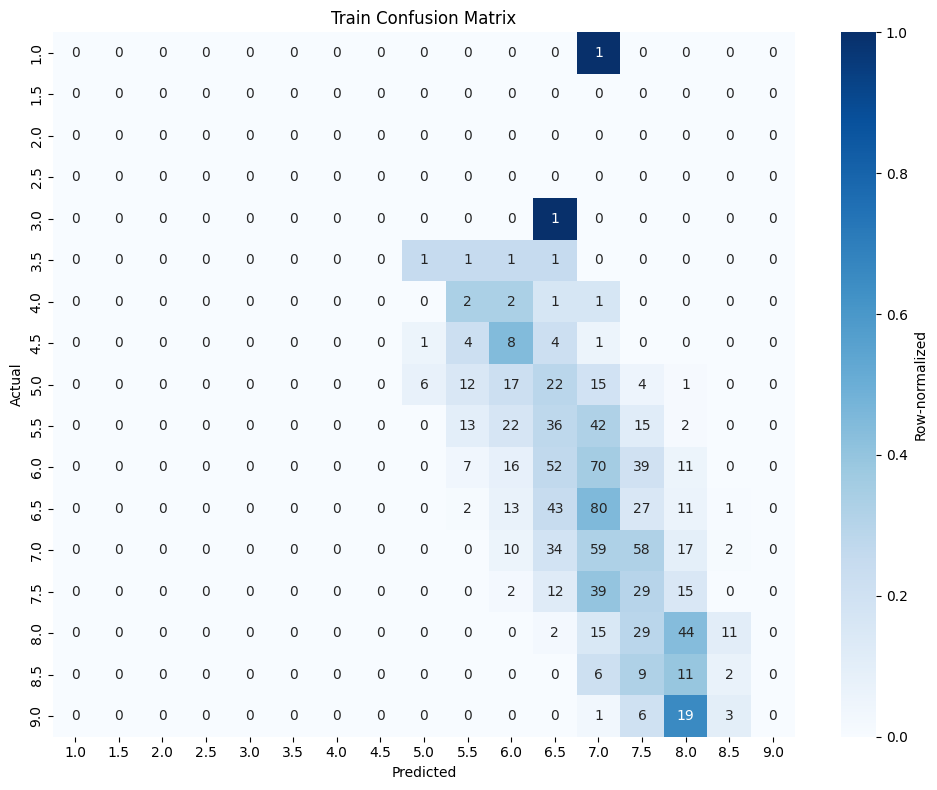

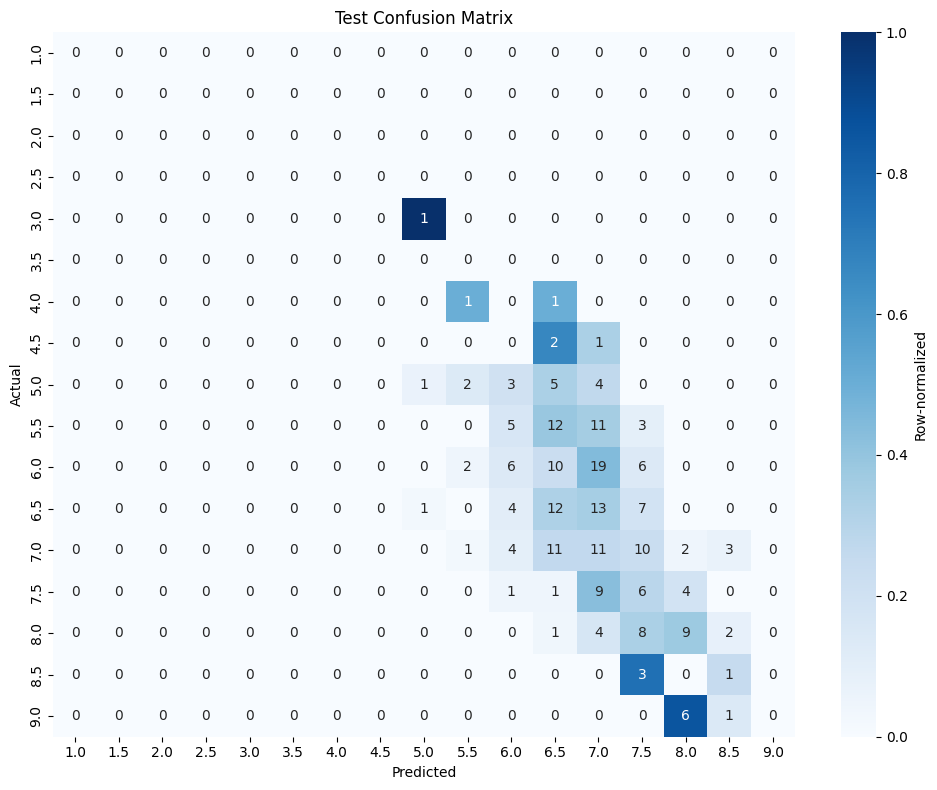

In [27]:
from sklearn.metrics import confusion_matrix

def plot_confusion(y_true, y_pred, title="Confusion Matrix (rounded to 0.5)"):
    # Round to nearest 0.5 band
    y_true_r = np.round(np.array(y_true) * 2) / 2
    y_pred_r = np.round(np.array(y_pred) * 2) / 2

    labels = np.arange(1.0, 9.5, 0.5)
    labels_str = [f"{l:.1f}" for l in labels]

    y_true_str = [f"{x:.1f}" for x in y_true_r]
    y_pred_str = [f"{x:.1f}" for x in y_pred_r]

    cm = confusion_matrix(y_true_str, y_pred_str, labels=labels_str)
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues",
                xticklabels=labels_str, yticklabels=labels_str,
                cbar_kws={"label": "Row-normalized"})
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Use train or test
plot_confusion(train_true, train_pred, "Train Confusion Matrix")
plot_confusion(test_true, test_pred, "Test Confusion Matrix")